### Семинар (практическая работа) 1.2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
%matplotlib inline

In [2]:
n = 1024
time_signal = 1
t = np.linspace(0, time_signal, n, endpoint=True)
dn = np.random.random(len(t))
w = 2 + 17
ds = (20 * np.sin((2 * np.pi) * 2 * w * t) + 10 * np.sin((2 * np.pi) * 6 * w * t)) + dn

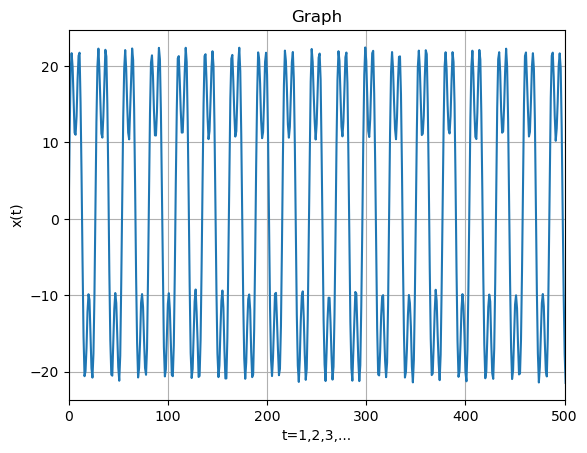

In [3]:
plt.plot(ds)
plt.xlabel('t=1,2,3,...')
plt.xlim(0,500)
plt.ylabel('x(t)')
plt.title('Graph')
plt.grid()
plt.show()

In [4]:
T = np.arange(n)
k = np.arange(n).reshape(n, 1)

In [5]:
Mm = np.exp(-2j * np.pi * k * T / n)
print(Mm.shape)

(1024, 1024)


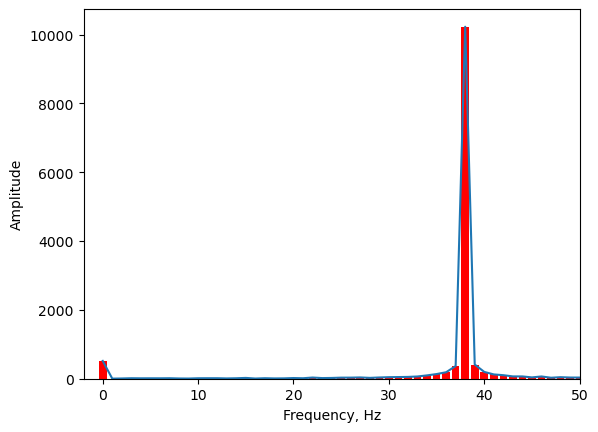

In [6]:
spectrum = np.dot(Mm, ds)

N = len(spectrum)
freq = np.arange(N) / time_signal

plt.figure()
plt.plot(freq, abs(spectrum))
plt.xlim(-2, 50)
plt.bar(freq, abs(spectrum), color='red')
plt.ylabel('Amplitude')
plt.xlabel('Frequency, Hz')
plt.show()

In [7]:
sizes = [100, 1000, 10000]
results = []

for n in sizes:

    time_signal = 1
    t = np.linspace(0, time_signal, n, endpoint=True)
    dn = np.random.random(len(t))
    w = 2 + 17

    ds = (20 * np.sin((2 * np.pi) * 2 * w * t) +
          10 * np.sin((2 * np.pi) * 6 * w * t)) + dn

    T = np.arange(n)
    k = np.arange(n).reshape(n, 1)

    start = time.perf_counter()

    Mm = np.exp(-2j * np.pi * k * T / n)
    spectrum = np.dot(Mm, ds)

    end = time.perf_counter()

    execution_time = end - start

    results.append({
        "N": n,
        "Time (sec)": execution_time
    })

In [8]:
df = pd.DataFrame(results)
df

,N,Time (sec)
0,100,0.001108
1,1000,0.042432
2,10000,3.910723


В результате выполнения был реализован и протестирован алгоритм наивного ДПФ. Экспериментально подтверждена его квадратичная вычислительная сложность O(N^2)-зависимость времени выполнения от размера входных данных хорошо аппроксимируется функцией T=C*N^2.